# Prac 03. Part 1

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

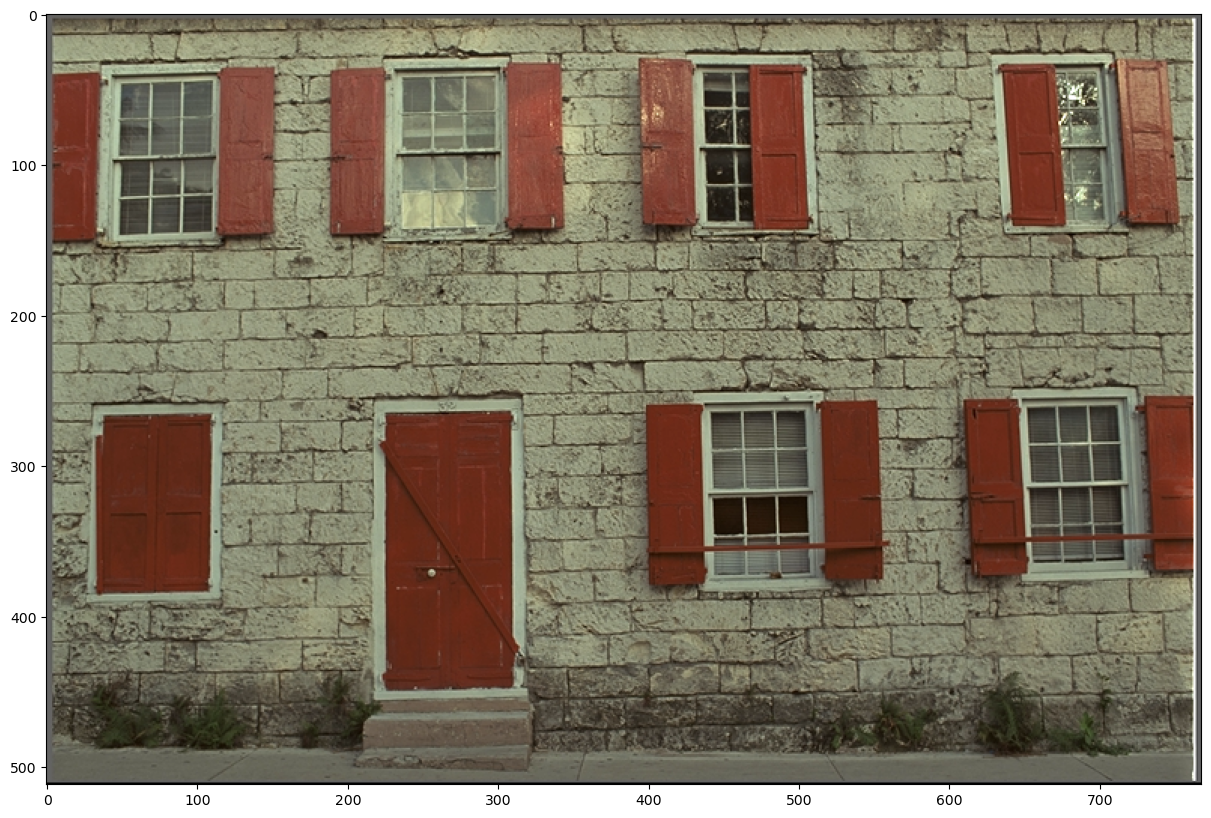

In [2]:
img = cv2.imread('../data/kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [3]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, (5, 5), 1.0)

original_f = img.astype(np.float32)
unsharp_f = unsharp.astype(np.float32)

In [4]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = original_f - unsharp_f

In [5]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
amount = 1.5 
sharpened_f = original_f + diff * amount

sharpened = np.clip(sharpened_f, 0, 255).astype(np.uint8)

(<Axes: title={'center': 'Sharpened'}>,
 Text(0.5, 1.0, 'Sharpened'))

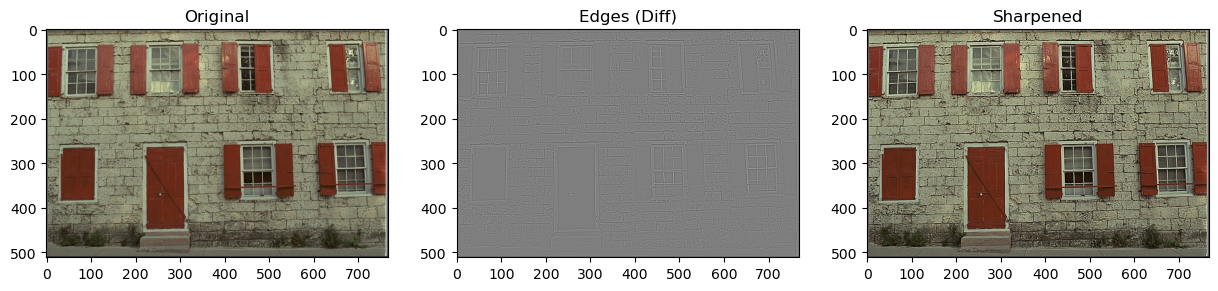

In [6]:
plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.subplot(132), plt.imshow(np.clip(diff + 127, 0, 255).astype(np.uint8)), plt.title('Edges (Diff)')
plt.subplot(133), plt.imshow(sharpened), plt.title('Sharpened')

### Questions
* What is a good (reasonable) value for the `amount` parameter?
    - typically between 0.5 and 1.5. This provides a noticeable boost in clarity without looking artificial.
* What happens if it is too small?
    - If the value is near zero, the resulting image will look identical to the original, with no perceptible sharpening of edges.
* What happens if it is too large?
    - the image develops heavy halos around edges and significantly amplifies sensor noise, making the photo look grainy and "over-processed."